<a href="https://colab.research.google.com/github/klaudiaajuszczykk/data-science-bootcamp/blob/main/dane1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import pandas as pd
import numpy as np

In [23]:
def fetch_financial_data(company='AMZN'):
  import pandas_datareader.data as web
  return web.DataReader(name=company, data_source='stooq')

  df=fetch_financial_data()
  df.info()


In [25]:
import yfinance as yf

def fetch_financial_data(company='MSFT'):
    return yf.download(company, progress=False)

df = fetch_financial_data('MSFT')
df.info()

/tmp/ipykernel_393/3313294703.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  return yf.download(company, progress=False)


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 20 entries, 2026-06-15 to 2026-07-14
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   (Close, MSFT)   20 non-null     float64
 1   (High, MSFT)    20 non-null     float64
 2   (Low, MSFT)     20 non-null     float64
 3   (Open, MSFT)    20 non-null     float64
 4   (Volume, MSFT)  20 non-null     int64  
dtypes: float64(4), int64(1)
memory usage: 960.0 bytes


In [40]:
print(df.columns)

MultiIndex([(  'Close', 'MSFT'),
            (   'High', 'MSFT'),
            (    'Low', 'MSFT'),
            (   'Open', 'MSFT'),
            ( 'Volume', 'MSFT'),
            ('Average',     '')],
           names=['Price', 'Ticker'])


In [29]:
df.head()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2026-06-15,399.760010,401.750000,392.850006,396.799988,32266400
2026-06-16,393.829987,396.839996,390.690002,395.790009,31506800
2026-06-17,378.910004,390.369995,377.320007,390.250000,41987800
2026-06-18,379.399994,381.369995,373.279999,377.820007,59714200
2026-06-22,367.339996,381.630005,367.070007,375.739990,45171100


In [30]:
df.describe()

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
count,20.000000,20.000000,20.000000,20.000000,2.000000e+01
mean,380.244496,385.628494,374.782503,380.508749,4.604024e+07
std,11.259267,8.972960,11.614777,10.487405,3.530302e+07
min,352.829987,364.230011,349.200012,357.149994,1.223000e+07
25%,373.007492,380.095001,367.355011,373.932510,3.063678e+07
50%,383.809998,386.529953,376.105011,381.667496,4.131770e+07
75%,387.264992,391.982506,382.050003,387.762497,4.589478e+07
max,399.760010,401.750000,392.850006,396.799988,1.862016e+08


In [31]:
df.head(3)

Price,Close,High,Low,Open,Volume
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT
Date,,,,,
2026-06-15,399.760010,401.750000,392.850006,396.799988,32266400
2026-06-16,393.829987,396.839996,390.690002,395.790009,31506800
2026-06-17,378.910004,390.369995,377.320007,390.250000,41987800


In [41]:
df["Average"] = (df[("Open", "MSFT")] + df[("Close", "MSFT")]) / 2
df.head()

Price,Close,High,Low,Open,Volume,Average
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,
Date,,,,,,
2026-06-15,399.760010,401.750000,392.850006,396.799988,32266400,398.279999
2026-06-16,393.829987,396.839996,390.690002,395.790009,31506800,394.809998
2026-06-17,378.910004,390.369995,377.320007,390.250000,41987800,384.580002
2026-06-18,379.399994,381.369995,373.279999,377.820007,59714200,378.610001
2026-06-22,367.339996,381.630005,367.070007,375.739990,45171100,371.539993


In [42]:
df=df.sort_index()
df.head()

Price,Close,High,Low,Open,Volume,Average
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,
Date,,,,,,
2026-06-15,399.760010,401.750000,392.850006,396.799988,32266400,398.279999
2026-06-16,393.829987,396.839996,390.690002,395.790009,31506800,394.809998
2026-06-17,378.910004,390.369995,377.320007,390.250000,41987800,384.580002
2026-06-18,379.399994,381.369995,373.279999,377.820007,59714200,378.610001
2026-06-22,367.339996,381.630005,367.070007,375.739990,45171100,371.539993


In [46]:
df[['Close']].shift(1)


Price,Close
Ticker,MSFT
Date,
2026-06-15,NaN
2026-06-16,399.760010
2026-06-17,393.829987
2026-06-18,378.910004
2026-06-22,379.399994
2026-06-23,367.339996
2026-06-24,373.940002
2026-06-25,365.459991


In [47]:
df["Close_shift"]= df.Close.shift(1)
df.head()

Price,Close,High,Low,Open,Volume,Average,Close_shift
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,,
Date,,,,,,,
2026-06-15,399.760010,401.750000,392.850006,396.799988,32266400,398.279999,NaN
2026-06-16,393.829987,396.839996,390.690002,395.790009,31506800,394.809998,399.760010
2026-06-17,378.910004,390.369995,377.320007,390.250000,41987800,384.580002,393.829987
2026-06-18,379.399994,381.369995,373.279999,377.820007,59714200,378.610001,378.910004
2026-06-22,367.339996,381.630005,367.070007,375.739990,45171100,371.539993,379.399994


In [52]:
df['Daily_change']= df["Close","MSFT"] / df["Close_shift"] -1
df.head()

Price,Close,High,Low,Open,Volume,Average,Close_shift,Daily_change
Ticker,MSFT,MSFT,MSFT,MSFT,MSFT,,,
Date,,,,,,,,
2026-06-15,399.760010,401.750000,392.850006,396.799988,32266400,398.279999,NaN,NaN
2026-06-16,393.829987,396.839996,390.690002,395.790009,31506800,394.809998,399.760010,-0.014834
2026-06-17,378.910004,390.369995,377.320007,390.250000,41987800,384.580002,393.829987,-0.037884
2026-06-18,379.399994,381.369995,373.279999,377.820007,59714200,378.610001,378.910004,0.001293
2026-06-22,367.339996,381.630005,367.070007,375.739990,45171100,371.539993,379.399994,-0.031787


In [53]:
df.Daily_change.min()

-0.03788432424867805

In [54]:
df.Daily_change.max()

0.05708135763656941

In [59]:
import seaborn as sns
sns.set()


<Axes: >

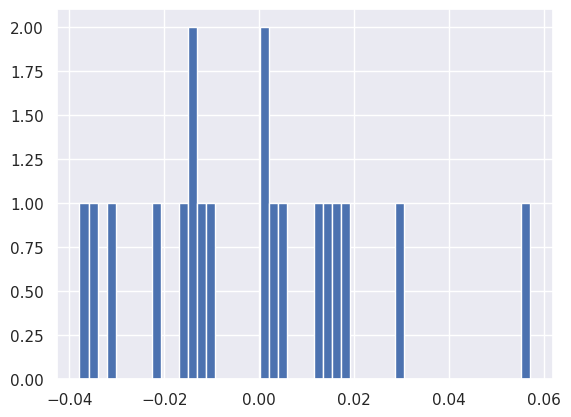

In [61]:
 df.Daily_change.hist(bins=50)

<Axes: xlabel='Date'>

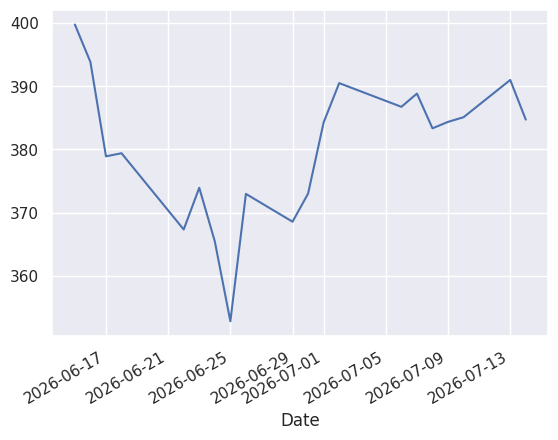

In [64]:
df['Close', 'MSFT'].plot()